# Scikit-Learn: Regression

**Topics covered:**
1. Linear Regression
2. Evaluating Regression (MAE, MSE, R2)
3. Polynomial Regression
4. Overfitting and Regularization (Ridge, Lasso)
5. Hyperparameter Selection (GridSearchCV)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

---
## 1. Linear Regression

Linear regression predicts a real-valued output from input features:

$$f(\mathbf{x}) = w_0 + w_1 x_1 + w_2 x_2 + \ldots + w_n x_n$$

The model learns the weights $w_i$ by minimizing the MSE on the training data.

Example: Simple linear regression (1 input feature)

$f(x) = w1x1 + w0 $

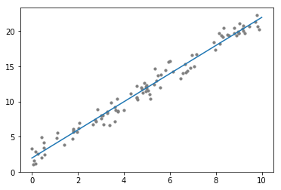


In [8]:
# Generate a simple dataset for 1D linear regression
np.random.seed(42)
X_simple = np.linspace(0, 10, 80).reshape(-1, 1)
y_simple = 2.5 * X_simple.ravel() + np.random.randn(80) * 2 +10

X_train, X_test, y_train, y_test = train_test_split(X_simple, y_simple, test_size=0.2, random_state=42)

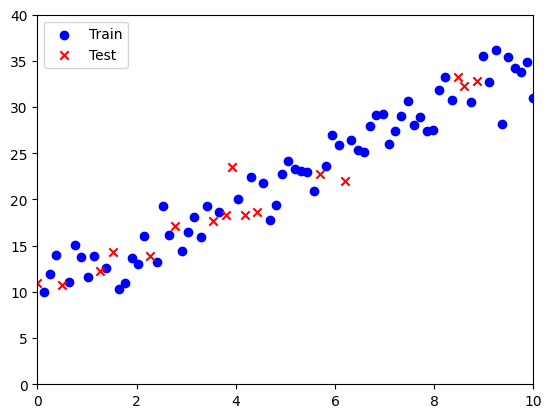

In [25]:
plt.scatter(X_train, y_train, color='blue', label='Train')
plt.scatter(X_test, y_test, color='red',marker='x', label='Test')

plt.xlim(0, 10)
plt.ylim(0, 40)
plt.legend()

- The hyperparameter fit_intercept specifies whether the intercept will be computed during training
- Default is True


In [26]:
from sklearn.linear_model import LinearRegression

# fit_intercept=True (default) means the model learns a bias term w0
reg = LinearRegression(fit_intercept=True)
reg.fit(X_train, y_train)
y_test_pred = reg.predict(X_test)

print(f"Intercept (w0): {reg.intercept_:.4f}")
print(f"Coefficient (w1): {reg.coef_[0]:.4f}")

Intercept (w0): 9.7632
Coefficient (w1): 2.5051


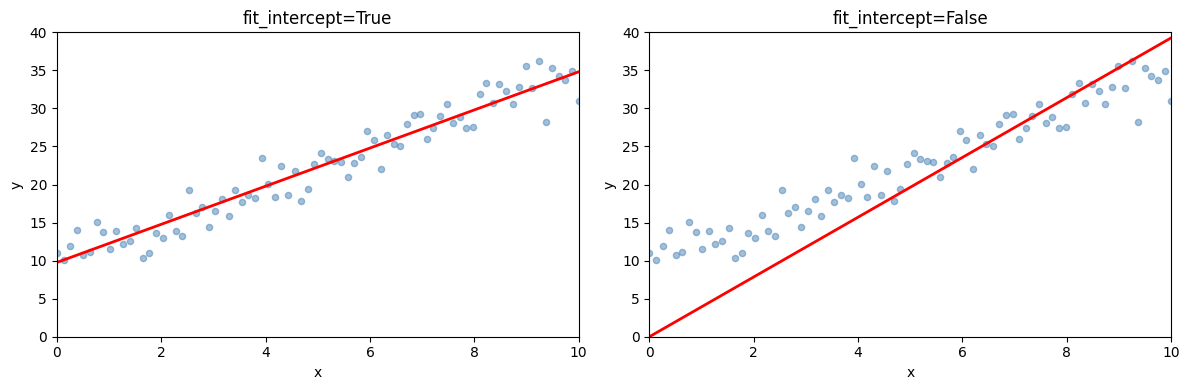

In [27]:
# Plot the regression line
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, fit_int, title in zip(axes, [True, False], ["fit_intercept=True", "fit_intercept=False"]):
    m = LinearRegression(fit_intercept=fit_int)
    m.fit(X_train, y_train)
    ax.scatter(X_simple, y_simple, color='steelblue', alpha=0.5, s=20)
    ax.plot(X_simple, m.predict(X_simple), color='red', linewidth=2)
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 40)


plt.tight_layout()

plt.show()

---
## 2. Evaluating Regression

Three main metrics are used:

**MAE** (Mean Absolute Error)  **Closer to 0 is better**:
$$MAE = \frac{1}{n} \sum_i |y_i - \hat{y}_i|$$

**MSE** (Mean Squared Error) - penalizes large errors more, but is lenient with small errors. **Closer to 0 is better**:
$$MSE = \frac{1}{n} \sum_i (y_i - \hat{y}_i)^2$$

**R2** (R squared) - proportion of variance explained by the model. **Closer to 1 is better**:
$$R^2 = 1 - \frac{MSE}{std^2}$$

In [28]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2  = r2_score(y_test, y_test_pred)
mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)

print(f"R2:  {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")

R2:  0.9397
MAE: 1.4640
MSE: 3.1357


### Cross-validation evaluation

`cross_val_score` splits the data into `cv` folds and returns one score per fold.

- For Regression, use `scoring='r2'` to get R2 scores per fold.
- alternatively, you can use `scoring='neg_mean_squared_error'` to get negative MSE scores (since higher is better for cross_val_score).

In [29]:
from sklearn.model_selection import cross_val_score

reg_cv = LinearRegression()
scores = cross_val_score(reg_cv, X_simple, y_simple, cv=5, scoring='r2')



print(f"R2 per fold: {scores.round(3)}")
print(f"Mean R2:     {scores.mean():.4f} (+/- {scores.std():.4f})")

R2 per fold: [-0.839  0.497  0.429  0.349 -0.396]
Mean R2:     0.0079 (+/- 0.5318)


---
## 3. Polynomial Regression

When the data does not follow a linear trend, we can:
1. Generate polynomial features from the input (e.g., $x^2, x^3, x_1 x_2$)
2. Apply standard linear regression on those new features

For input $[x_1, x_2]$ with degree 2:
$$[1,\ x_1,\ x_2,\ x_1^2,\ x_2^2,\ x_1 x_2]$$
$$\downarrow$$
$$f(x) = w_0 + w_1x_1 + w_2x_2 + w_3x_1^2 + w_4x_2^2 + w_5x_1x_2$$

In [66]:
# Generate non-linear data
np.random.seed(0)
X_nl = np.linspace(-3, 3, 100).reshape(-1, 1)
y_nl = (X_nl.ravel())**2 - 2 * X_nl.ravel() + np.random.randn(100) * 0.8 

X_tr, X_te, y_tr, y_te = train_test_split(X_nl, y_nl, test_size=0.2, random_state=42)

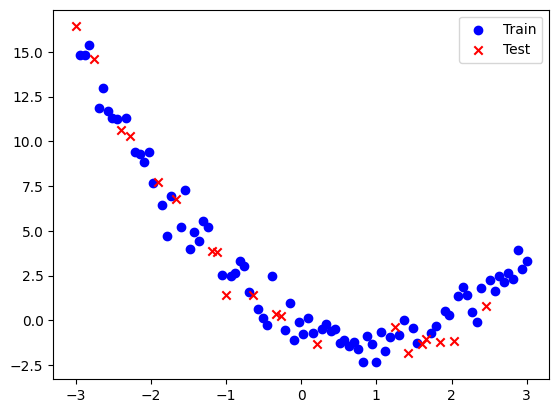

In [67]:
plt.scatter(X_tr, y_tr, color='blue', label='Train')
plt.scatter(X_te, y_te, color='red',marker='x', label='Test')

plt.legend()

In [75]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(5,interaction_only=False)
X_poly_tr = poly.fit_transform(X_tr)
X_poly_te = poly.transform(X_te)
print("Original features shape:", X_tr.shape)
print("Polynomial features shape:", X_poly_tr.shape)

print("Names:    ", poly.get_feature_names_out(['x1']))



Original features shape: (80, 1)
Polynomial features shape: (80, 6)
Names:     ['1' 'x1' 'x1^2' 'x1^3' 'x1^4' 'x1^5']


In [76]:
# Inspect the polynomial features generated
poly = PolynomialFeatures(degree=2, include_bias=True)
X_sample = np.array([[2.0, 3.0]])
X_poly = poly.fit_transform(X_sample)

print("Input:    ", X_sample)
print("Features: ", X_poly)
print("Names:    ", poly.get_feature_names_out(['x1', 'x2']))

Input:     [[2. 3.]]
Features:  [[1. 2. 3. 4. 6. 9.]]
Names:     ['1' 'x1' 'x2' 'x1^2' 'x1 x2' 'x2^2']


- Building a pipeline with polynomial features and linear regression
```
from sklearn.pipeline import make_pipeline
reg = make_pipeline(PolynomialFeatures(5), LinearRegression())
reg.fit(X_train, y_train)
y_test_pred = ret.predict(X_test)
```
- Pipelines are objects that allow concatenating multiple Scikit-learn models


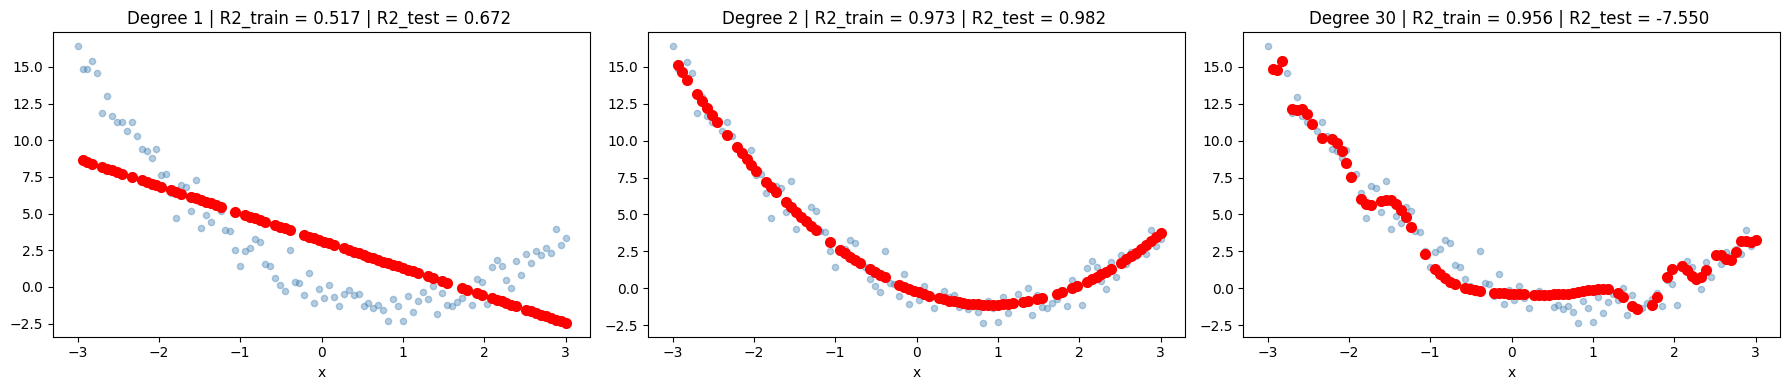

In [77]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Degree 1 (plain linear) vs Degree 2 (polynomial)
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
X_plot = np.linspace(-3, 3, 200).reshape(-1, 1)

for ax, deg in zip(axes, [1, 2, 30]):
    pipe = make_pipeline(PolynomialFeatures(deg), LinearRegression())
    pipe.fit(X_tr, y_tr)
    y_pred_tr = pipe.predict(X_tr)
    r2_train = r2_score(y_tr, pipe.predict(X_tr))
    r2_test = r2_score(y_te, pipe.predict(X_te))
    ax.scatter(X_nl, y_nl, color='steelblue', alpha=0.4, s=20)
    ax.scatter(X_tr, y_pred_tr, color='red', linewidth=2)
    ax.set_title(f"Degree {deg} | R2_train = {r2_train:.3f} | R2_test = {r2_test:.3f} ")
    ax.set_xlabel('x')

plt.tight_layout()
plt.show()

---
## 4. Overfitting and Regularization

A high-degree polynomial can **overfit** the training data: the model memorizes noise instead of learning the true pattern.

Strategies to avoid overfitting:
- Use more training data
- Use lower polynomial degree
- Use **regularization** (Ridge or Lasso)

Both Ridge and Lasso add a penalty on the coefficients to the MSE objective:

| Method | Objective |
|--------|-----------|
| Linear | $MSE$ |
| Ridge  | $MSE + \alpha \sum_i w_i^2$ |
| Lasso  | $MSE + \alpha \sum_i \|w_i\| $ |


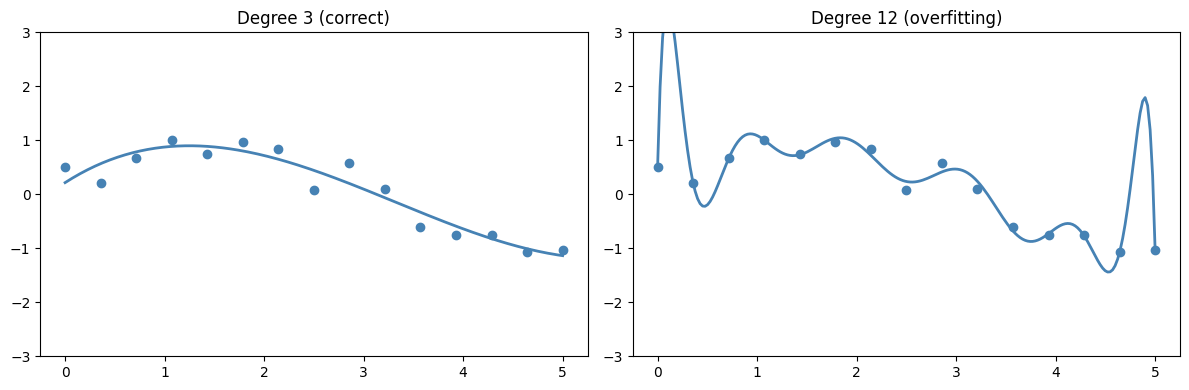

In [81]:
# Show overfitting with a very high degree on few samples
np.random.seed(7)
X_few = np.linspace(0, 5, 15).reshape(-1, 1)
y_few = np.sin(X_few.ravel()) + np.random.randn(15) * 0.3

X_plot = np.linspace(0, 5, 200).reshape(-1, 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, deg, title in zip(axes, [3, 12], ["Degree 3 (correct)", "Degree 12 (overfitting)"]):
    pipe = make_pipeline(PolynomialFeatures(deg), LinearRegression())
    pipe.fit(X_few, y_few)
    ax.scatter(X_few, y_few, color='steelblue', zorder=5)
    ax.plot(X_plot, pipe.predict(X_plot), color='steelblue', linewidth=2)
    ax.set_title(title)
    ax.set_ylim(-3, 3)

plt.tight_layout()
plt.show()

- Ridge tends to lower uniformly all the coefficients
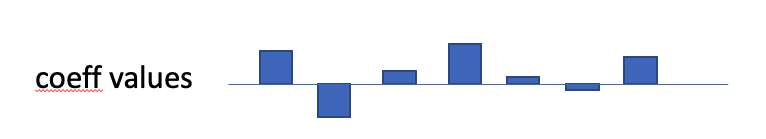


- Lasso tends to assign the value 0 to some coefficients (**feature selection**)
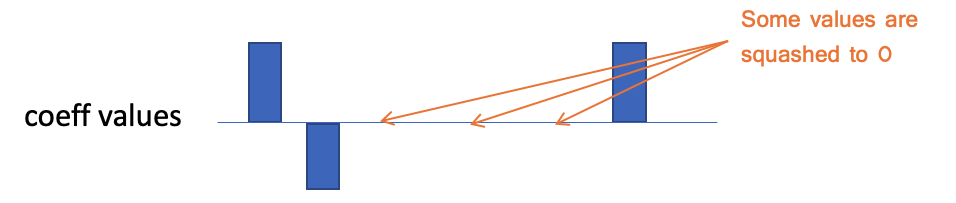

/Users/giordanopaoletti/Desktop/Laboratori/ds-ml-engineering-labs/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.917e-01, tolerance: 5.812e-04
  model = cd_fast.enet_coordinate_descent(


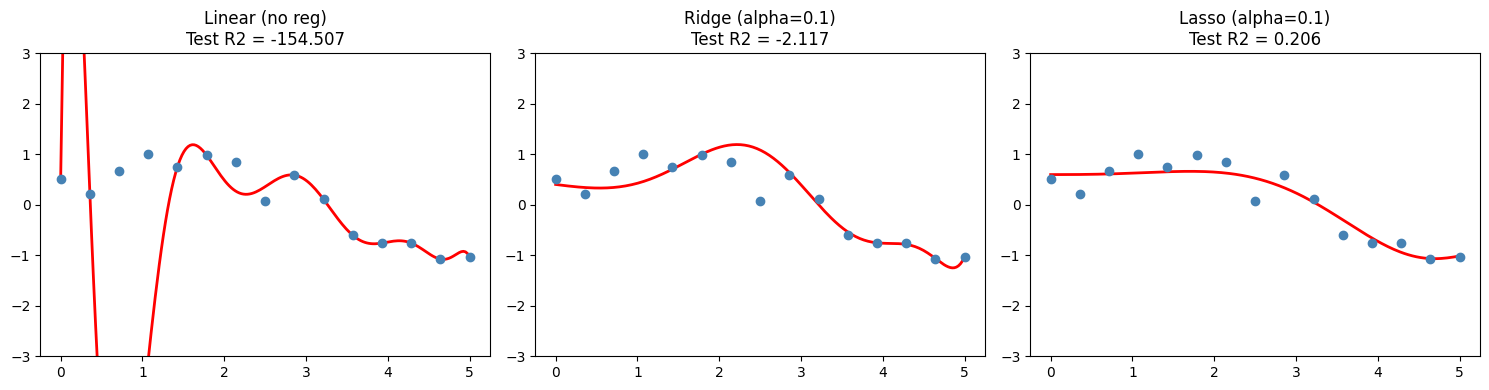

In [96]:
from sklearn.linear_model import Ridge, Lasso

# Compare LinearRegression, Ridge, and Lasso on an overfitting-prone setup
degree = 10
alpha = 0.1

models = {
    "Linear (no reg)": make_pipeline(PolynomialFeatures(degree), LinearRegression()),
    f"Ridge (alpha={alpha})": make_pipeline(PolynomialFeatures(degree), Ridge(alpha=alpha)),
    f"Lasso (alpha={alpha})": make_pipeline(PolynomialFeatures(degree), Lasso(alpha=alpha, max_iter=10000)),
}

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(X_few, y_few, test_size=0.25, random_state=1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, pipe) in zip(axes, models.items()):
    pipe.fit(X_tr2, y_tr2)
    r2 = r2_score(y_te2, pipe.predict(X_te2))
    ax.scatter(X_few, y_few, color='steelblue', zorder=5)
    ax.plot(X_plot, pipe.predict(X_plot), color='red', linewidth=2)
    ax.set_title(f"{name}\nTest R2 = {r2:.3f}")
    ax.set_ylim(-3, 3)

plt.tight_layout()
plt.show()

/Users/giordanopaoletti/Desktop/Laboratori/ds-ml-engineering-labs/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.732e-01, tolerance: 7.926e-04
  model = cd_fast.enet_coordinate_descent(


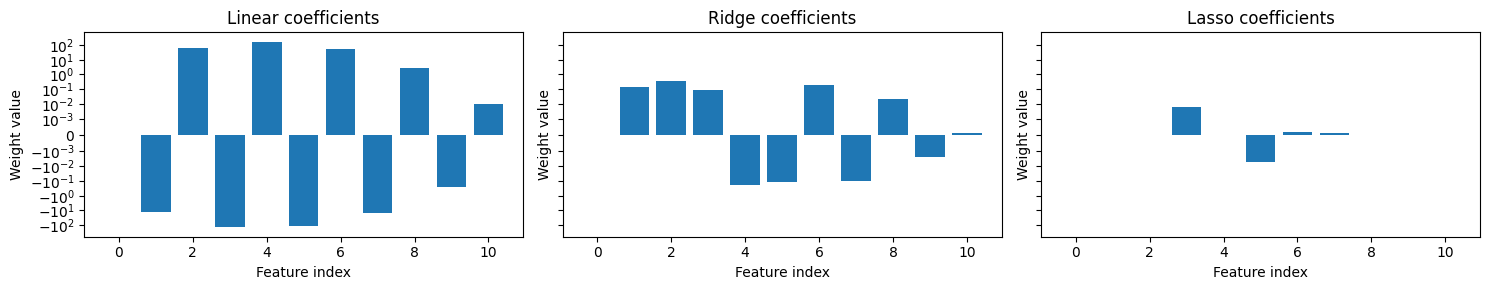

Lasso non-zero coefficients: 7 / 11


In [106]:
# Inspect coefficients: Ridge shrinks uniformly, Lasso forces many to zero
poly_base = PolynomialFeatures(degree)
X_poly_all = poly_base.fit_transform(X_few)

lin = LinearRegression().fit(X_poly_all, y_few)
rid = Ridge(alpha=alpha).fit(X_poly_all, y_few)
las = Lasso(alpha=alpha, max_iter=10000).fit(X_poly_all, y_few)

fig, axes = plt.subplots(1, 3, figsize=(15, 3), sharey=True)
for ax, model, title in zip(axes, [lin, rid, las], ["Linear", "Ridge", "Lasso"]):
    ax.bar(range(len(model.coef_)), model.coef_)
    ax.set_title(f"{title} coefficients")
    ax.set_xlabel("Feature index")
    ax.set_ylabel("Weight value")
    ax.set_yscale("symlog", linthresh=1e-3)


plt.tight_layout()
plt.show()
print(f"Lasso non-zero coefficients: {np.sum(las.coef_ != 0)} / {len(las.coef_)}")

---
## 5. Hyperparameter Selection

**Hyperparameters** (e.g., `alpha` in Ridge/Lasso, `degree` in PolynomialFeatures) are chosen by the user before training. **Parameters** (e.g., weights $w_i$) are learned during training.

You must **not** select hyperparameters by evaluating on the test set. This would leak test information into the training process.

Two valid approaches:
1. **Hold-out validation**: split training data into training + validation sets
2. **k-fold cross-validation**: rotate the validation partition across k folds

Scikit-learn provides `GridSearchCV` to automate approach 2.

In [107]:
# Generate a more realistic dataset
np.random.seed(10)
X_gs = np.linspace(-3, 3, 120).reshape(-1, 1)
y_gs = 0.5 * X_gs.ravel()**3 - X_gs.ravel() + np.random.randn(120) * 1.5

X_tr_gs, X_te_gs, y_tr_gs, y_te_gs = train_test_split(X_gs, y_gs, test_size=0.2, random_state=0)

In [109]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'ridge__alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'polynomialfeatures__degree': [2, 3, 4, 5]
}

# Build pipeline and run grid search
pipe_gs = make_pipeline(PolynomialFeatures(), Ridge())
gridsearch = GridSearchCV(pipe_gs, param_grid, scoring='r2', cv=5)
gridsearch.fit(X_tr_gs, y_tr_gs)

print("Best parameters:", gridsearch.best_params_)
print(f"Best CV R2:       {gridsearch.best_score_:.4f}")

Best parameters: {'polynomialfeatures__degree': 4, 'ridge__alpha': 1.0}
Best CV R2:       0.8213


In [110]:
# Evaluate the best model on the (held-out) test set
best_model = gridsearch.best_estimator_
y_pred_gs = best_model.predict(X_te_gs)

print(f"Test R2:  {r2_score(y_te_gs, y_pred_gs):.4f}")
print(f"Test MAE: {mean_absolute_error(y_te_gs, y_pred_gs):.4f}")
print(f"Test MSE: {mean_squared_error(y_te_gs, y_pred_gs):.4f}")

Test R2:  0.8653
Test MAE: 1.1417
Test MSE: 2.0666


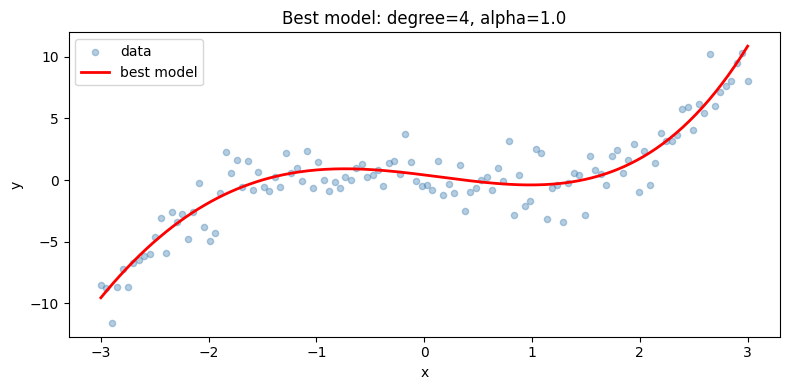

In [111]:
# Visualize the best model fit
X_plot_gs = np.linspace(-3, 3, 300).reshape(-1, 1)

plt.figure(figsize=(8, 4))
plt.scatter(X_gs, y_gs, color='steelblue', alpha=0.4, s=20, label='data')
plt.plot(X_plot_gs, best_model.predict(X_plot_gs), color='red', linewidth=2, label='best model')
plt.title(f"Best model: degree={gridsearch.best_params_['polynomialfeatures__degree']}, "
          f"alpha={gridsearch.best_params_['ridge__alpha']}")
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.tight_layout()
plt.show()

Mean CV R2 scores:
param_ridge__alpha                0.001    0.010    0.100    1.000    10.000   \
param_polynomialfeatures__degree                                                
2                                   0.448    0.448    0.448    0.448    0.448   
3                                   0.820    0.820    0.820    0.820    0.817   
4                                   0.821    0.821    0.821    0.821    0.819   
5                                   0.818    0.818    0.818    0.819    0.817   

param_ridge__alpha                100.000  
param_polynomialfeatures__degree           
2                                   0.398  
3                                   0.791  
4                                   0.791  
5                                   0.811  


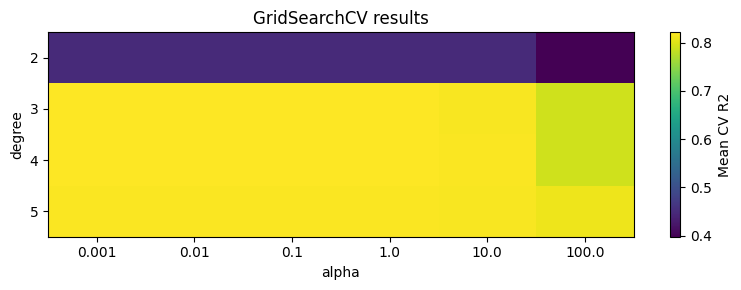

In [112]:
# Inspect mean CV scores across the grid
import pandas as pd

results = pd.DataFrame(gridsearch.cv_results_)
pivot = results.pivot_table(
    values='mean_test_score',
    index='param_polynomialfeatures__degree',
    columns='param_ridge__alpha'
)

print("Mean CV R2 scores:")
print(pivot.round(3))

plt.figure(figsize=(8, 3))
plt.imshow(pivot.values, aspect='auto', cmap='viridis')
plt.colorbar(label='Mean CV R2')
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xlabel('alpha')
plt.ylabel('degree')
plt.title('GridSearchCV results')
plt.tight_layout()
plt.show()